# Candle Notebook: Image Store + Egui Window Demo
This consolidated notebook shows how to: 
1. Configure and use the image store (relative directory `images_store`).
2. Generate and display tensors as images (grayscale and RGB).
3. Use the pseudo *egui window* HTML helpers to lay out panels.
4. Persist images to disk while also showing inline previews.

Prereqs: The helper crate `candle_notebooks` in `0aEXPLORATION/candle_notebooks` must be available to the evcxr kernel (usually by `:dep` path or installing the crate).

In [56]:
// Cell 1 - Dependencies: link local crates so we can `use` them below.
// Tip: If you change crate code, re-run this cell to rebuild + relink.
:dep candle = { package = "candle-core", path = "../../candle-core" }
:dep candle_nn = { package = "candle-nn", path = "../../candle-nn" }
:dep candle_notebooks = { package = "candle-notebooks", path = "../candle_notebooks" }
:dep candle_tensor_augment = { path = "../candle_tensor_augment" }
// (Optional) add image / display deps if helpers rely on them.
// Note: Avoid importing DType here; subsequent cells will import only what they use.

In [57]:
// Cell 2 - set cwd to repo root using helper (optional, for relative paths).
candle_notebooks::set_notebook_cwd().unwrap();
println!("CWD set to repo root: {:?}", std::env::current_dir().unwrap());

Notebook CWD set to repository root: /home/rustuser/projects/rust/from_github/candle/0aEXPLORATION/candle_notebooks
CWD set to repo root: "/home/rustuser/projects/rust/from_github/candle/0aEXPLORATION/candle_notebooks"
CWD set to repo root: "/home/rustuser/projects/rust/from_github/candle/0aEXPLORATION/candle_notebooks"


In [58]:
// Cell 3 - Configure image store output directory for saved PNGs.
use candle_notebooks as nb;
// Set the relative directory where generated images will be stored.
nb::set_image_store_rel_dir("images_store").unwrap();
println!("Image store directory: images_store");

Image store directory: images_store


Saving images to: /home/rustuser/projects/rust/from_github/candle/0aEXPLORATION/candle_notebooks/images_store

Caption: Sine wave grayscale  Dims: 128×256


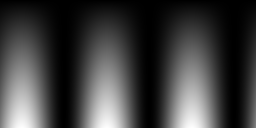

In [59]:
// Cell 4 - Analytical image: Sine wave grayscale
let w = 256; let h = 128;
let mut data = Vec::with_capacity(w*h);
for y in 0..h {
    for x in 0..w {
        let fx = x as f32 / (w as f32 - 1.0);
        let val = ((fx * std::f32::consts::TAU * 3.0).sin() * 0.5 + 0.5) * (y as f32 / h as f32);
        data.push(val);
    }
}
let img = Tensor::from_vec(data, (h, w), &Device::Cpu).unwrap();
nb::show_tensor_gray_captioned(&img, Some("Sine wave grayscale"), Some("sin(3x) modulated by y"), None).unwrap();

## 1. Generate Sample Tensors
We'll create: 
- A simple grayscale ramp 
- A small RGB gradient image

Caption: Grayscale ramp  Dims: 32×32


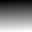

In [60]:
// Cell 5 - Create a 16x16 grayscale ramp and display it.
let w = 32; let h = 32;
let data: Vec<f32> = (0..(w*h))
    .map(|i| i as f32 / ((w*h - 1) as f32))
    .collect();
let ramp = Tensor::from_vec(data, (h, w), &Device::Cpu).unwrap();
nb::show_tensor_gray_captioned(&ramp, Some("Grayscale ramp"), Some("u8->f32 normalized [0,1]"), None).unwrap();

Caption: RGB gradient  Dims: 3×64×64


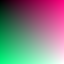

In [61]:
// Cell 6 - Create a 32x32 RGB gradient and display it.
let w = 64; let h = 64;
let mut r: Vec<f32> = Vec::with_capacity((w*h) as usize);
let mut g: Vec<f32> = Vec::with_capacity((w*h) as usize);
let mut b: Vec<f32> = Vec::with_capacity((w*h) as usize);
for y in 0..h {
  for x in 0..w {
    let rf = x as f32 / ((w - 1) as f32);
    let gf = y as f32 / ((h - 1) as f32);
    let bf = (rf + gf) * 0.5;
    r.push(rf);
    g.push(gf);
    b.push(bf);
  }
}
// Concatenate into channels-first layout [3, H, W]
let mut chw: Vec<f32> = Vec::with_capacity((w*h*3) as usize);
chw.extend_from_slice(&r);
chw.extend_from_slice(&g);
chw.extend_from_slice(&b);
let img = Tensor::from_vec(chw, (3, h, w), &Device::Cpu).unwrap();
nb::show_tensor_rgb_captioned(&img, Some("RGB gradient"), Some("built as f32 [0,1] in CHW"), None).unwrap();

## 2. Compose an Egui-style Window
Use the pseudo-egui helpers to layout content blocks (HTML output).

In [62]:
// Cell 7 - Build a simple two-column layout and open a pseudo window (HTML).
use candle_notebooks::egui_window;
let left = "<div><h4>Left Panel</h4><p>Some controls / text here.</p></div>";
let right = "<div><h4>Right Panel</h4><p>Stats / logs can go here.</p></div>";
let layout = format!("<div style='display:flex;gap:12px'><div style='flex:1'>{}</div><div style='flex:1'>{}</div></div>", left, right);
egui_window::open("Demo Window", &layout);

Demo Window 
 Left Panel Some controls / text here. Right Panel Stats / logs can go here.

## 3. Embed Saved Images in the Egui-style Window
We can reference the stored image filenames and build an HTML snippet to display them side-by-side.

Image Gallery 
 
 Gray Ramp 
 RGB Gradient
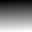
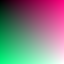

In [63]:
// Cell 8 - Open a gallery window with images from the last-generated tensors.
use candle_notebooks::egui_window;
// Re-generate the same tensors quickly for gallery embed.
let w1 = 32; let h1 = 32;
let gray_vals: Vec<f32> = (0..(w1*h1)).map(|i| i as f32 / ((w1*h1 - 1) as f32)).collect();
let gray = Tensor::from_vec(gray_vals, (h1, w1), &Device::Cpu).unwrap();
let gray_url = nb::tensor_to_png_data_url_gray(&gray).unwrap();
let w2 = 64; let h2 = 64;
let mut r: Vec<f32> = Vec::with_capacity((w2*h2) as usize);
let mut g: Vec<f32> = Vec::with_capacity((w2*h2) as usize);
let mut b: Vec<f32> = Vec::with_capacity((w2*h2) as usize);
for y in 0..h2 { for x in 0..w2 {
  let rf = x as f32 / ((w2 - 1) as f32);
  let gf = y as f32 / ((h2 - 1) as f32);
  let bf = (rf + gf) * 0.5;
  r.push(rf); g.push(gf); b.push(bf);
}}
let mut chw: Vec<f32> = Vec::with_capacity((w2*h2*3) as usize);
chw.extend_from_slice(&r); chw.extend_from_slice(&g); chw.extend_from_slice(&b);
let rgb = Tensor::from_vec(chw, (3, h2, w2), &Device::Cpu).unwrap();
let rgb_url = nb::tensor_to_png_data_url_rgb(&rgb).unwrap();
let img_html = format!(
  "<div style='display:flex;gap:12px;'>\n  <figure><img src='{}' width='128'/><figcaption>Gray Ramp</figcaption></figure>\n  <figure><img src='{}' width='128'/><figcaption>RGB Gradient</figcaption></figure>\n</div>",
  gray_url, rgb_url
);
egui_window::open("Image Gallery", &img_html);

In [64]:
// Cell 9 - Example code for the selected cell
use candle_notebooks::helper;
let example_message = "Hello, Candle!";
let morse = helper::to_morse_code(example_message);
println!("Morse Code: {}", morse);

Morse Code: .... . .-.. .-.. --- / -.-. .- -. -.. .-.. .


Caption: Expr: sin(2πx)cos(2πy)  Dims: 128×128


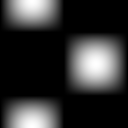

In [66]:
// Cell 10
/* use the provided trait that realizes an operation that can parse math-expressions (string),
   according to the math a candle-tensor is filled with what the math tells it do. keywords ; synthetic data viz */
// ../candle_tensor_augment/src/lib.rs

use candle::{Device, Tensor};
use candle_notebooks as nb;
use candle_tensor_augment::TensorMathFill;

let device = Device::Cpu;
let expr = "sin(x * 6.28318) * cos(y * 6.28318)"; // 2*pi
let t = Tensor::fill_with_expr(128, 128, expr, &device).unwrap();

// Show it as grayscale and auto-save via captioned helper
nb::show_tensor_gray_captioned(&t, Some("Expr: sin(2πx)cos(2πy)"), Some("TensorMathFill"), None).unwrap();